In [234]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [182]:
df=pd.read_csv('youtube_data.csv')

In [183]:
df.head()

,video_id,views,likes,comments,channel_id,channel_name,date,duration,category_id,genre,subscribers,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,49p7hMbCpys,61074032,2948352,4611,UCglXlpWjIi95auM3umWWLdw,Tech Master Shorts,2023-05-04 08:03:00+00:00,56,28,Technology,"26,500,000.00",NaN,NaN,NaN
1,ofzwCrlxywc,59182092,1955798,1576,UCoL68NLLSUQqEDwMZPvrdEg,TechBurner Shorts,2023-09-01 17:13:48+00:00,35,28,Technology,"6,390,000.00",NaN,NaN,NaN
2,IZl5ipoTIEA,53162940,2647209,3112,UCMiJRAwDNSNzuYeN2uWa0pA,Mrwhosetheboss,2023-03-14 10:14:49+00:00,60,28,Technology,"22,200,000.00",NaN,NaN,NaN
3,FNnK1J-BdiM,43007923,1908958,7863,UCBJycsmduvYEL83R_U4JriQ,Marques Brownlee,2023-06-22 04:03:29+00:00,56,28,Technology,"20,700,000.00",NaN,NaN,NaN
4,vkBQW8NZk9k,39995391,1962796,5058,UCMiJRAwDNSNzuYeN2uWa0pA,Mrwhosetheboss,2023-05-14 13:01:39+00:00,60,28,Technology,"22,200,000.00",NaN,NaN,NaN


## Data Cleaning

In [184]:
cols_to_drop = ['Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13']
df.drop(columns=cols_to_drop, inplace=True)

df.head()

,video_id,views,likes,comments,channel_id,channel_name,date,duration,category_id,genre,subscribers
0,49p7hMbCpys,61074032,2948352,4611,UCglXlpWjIi95auM3umWWLdw,Tech Master Shorts,2023-05-04 08:03:00+00:00,56,28,Technology,"26,500,000.00"
1,ofzwCrlxywc,59182092,1955798,1576,UCoL68NLLSUQqEDwMZPvrdEg,TechBurner Shorts,2023-09-01 17:13:48+00:00,35,28,Technology,"6,390,000.00"
2,IZl5ipoTIEA,53162940,2647209,3112,UCMiJRAwDNSNzuYeN2uWa0pA,Mrwhosetheboss,2023-03-14 10:14:49+00:00,60,28,Technology,"22,200,000.00"
3,FNnK1J-BdiM,43007923,1908958,7863,UCBJycsmduvYEL83R_U4JriQ,Marques Brownlee,2023-06-22 04:03:29+00:00,56,28,Technology,"20,700,000.00"
4,vkBQW8NZk9k,39995391,1962796,5058,UCMiJRAwDNSNzuYeN2uWa0pA,Mrwhosetheboss,2023-05-14 13:01:39+00:00,60,28,Technology,"22,200,000.00"


In [185]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   video_id      8000 non-null   object 
 1   views         8000 non-null   int64  
 2   likes         8000 non-null   int64  
 3   comments      8000 non-null   int64  
 4   channel_id    8000 non-null   object 
 5   channel_name  8000 non-null   object 
 6   date          8000 non-null   object 
 7   duration      8000 non-null   int64  
 8   category_id   8000 non-null   int64  
 9   genre         8000 non-null   object 
 10  subscribers   7997 non-null   float64
dtypes: float64(1), int64(5), object(5)
memory usage: 687.6+ KB


In [186]:
df['subscribers'].isnull().sum()

np.int64(3)

In [187]:
print("total rows:", len(df))

dup=df[df.duplicated(subset="video_id",keep=False)]
print("No. of duplicate rows", dup.shape[0])
print(dup.sort_values("video_id"))


total rows: 8000
No. of duplicate rows 7
     video_id    views   likes  comments                channel_id  \
99     #NAME?  5710236  173715       500  UC7ySZBzw3bqY7MTk6irMd0Q   
7606   #NAME?  4710156  117082      4770  UCMiJRAwDNSNzuYeN2uWa0pA   
7755   #NAME?   148604    5741       220  UCCiGY0qGJ6ArOh8FpwgmxJQ   
7795   #NAME?   108803     504        40  UCUq3Rn72jfQ-86CaCxj7XzA   
7862   #NAME?    29897       0         2  UCAnUCptKa5btEzfpaepOpLw   
7939   #NAME?  2227984  165932      1107  UCFar6t6OF-q2Y6rBuoDhpOg   
7986   #NAME?  5615167   34686       772  UCOKWRzGE08ESvQ5JwxiwWKQ   

              channel_name                       date  duration  category_id  \
99    SimpleGhar Malayalam  2023-09-09 12:30:00+00:00        36           28   
7606        Mrwhosetheboss  2025-12-22 12:18:02+00:00      1653           28   
7755                  ryan  2026-01-19 20:29:22+00:00        70           22   
7795          Created Tech  2026-01-10 08:58:47+00:00      1235           28  

In [188]:
duplicate_counts = df["video_id"].value_counts()
print(duplicate_counts[duplicate_counts > 1])

df.head()

video_id
#NAME?    7
Name: count, dtype: int64


,video_id,views,likes,comments,channel_id,channel_name,date,duration,category_id,genre,subscribers
0,49p7hMbCpys,61074032,2948352,4611,UCglXlpWjIi95auM3umWWLdw,Tech Master Shorts,2023-05-04 08:03:00+00:00,56,28,Technology,"26,500,000.00"
1,ofzwCrlxywc,59182092,1955798,1576,UCoL68NLLSUQqEDwMZPvrdEg,TechBurner Shorts,2023-09-01 17:13:48+00:00,35,28,Technology,"6,390,000.00"
2,IZl5ipoTIEA,53162940,2647209,3112,UCMiJRAwDNSNzuYeN2uWa0pA,Mrwhosetheboss,2023-03-14 10:14:49+00:00,60,28,Technology,"22,200,000.00"
3,FNnK1J-BdiM,43007923,1908958,7863,UCBJycsmduvYEL83R_U4JriQ,Marques Brownlee,2023-06-22 04:03:29+00:00,56,28,Technology,"20,700,000.00"
4,vkBQW8NZk9k,39995391,1962796,5058,UCMiJRAwDNSNzuYeN2uWa0pA,Mrwhosetheboss,2023-05-14 13:01:39+00:00,60,28,Technology,"22,200,000.00"


In [189]:
df= df.sort_values("views", ascending=False).drop_duplicates(subset="video_id", keep="first")

df.head()


,video_id,views,likes,comments,channel_id,channel_name,date,duration,category_id,genre,subscribers
5194,9_WBQISVHnw,2307901697,2719637,0,UCK5Q72Uyo73uRPk8PmM2A3w,Genevieve's Playhouse - Learning Videos for Kids,2019-01-05 16:52:49+00:00,623,1,Education,"49,200,000.00"
2912,CnSylwYOu1E,2178021347,20943413,0,UCgFXm4TI8htWmCyJ6cVPG_A,Toys and Colors,2023-05-05 11:30:04+00:00,30,24,Entertainment,"82,000,000.00"
3515,hTqtGJwsJVE,1814220195,2853557,0,UCG2CL6EUjG8TVT1Tpl9nJdg,Ms Rachel - Toddler Learning Videos,2022-03-02 17:30:10+00:00,3621,27,Education,"18,600,000.00"
7091,dNCWe_6HAM8,1184538229,15369289,1116739,UCOmHUn--16B90oW2L6FRR3A,BLACKPINK,2021-09-23 15:00:16+00:00,171,10,Finance,"99,700,000.00"
6000,GQTUYAhJzY8,1128446716,17865538,44657,UCIH9-O5pX3Qr9bESZB3LYdw,Littos Media,2024-03-20 13:27:10+00:00,15,26,Education,"8,480,000.00"


In [190]:
df["video_id"].value_counts().max()


1

In [191]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7994 entries, 5194 to 1748
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   video_id      7994 non-null   object 
 1   views         7994 non-null   int64  
 2   likes         7994 non-null   int64  
 3   comments      7994 non-null   int64  
 4   channel_id    7994 non-null   object 
 5   channel_name  7994 non-null   object 
 6   date          7994 non-null   object 
 7   duration      7994 non-null   int64  
 8   category_id   7994 non-null   int64  
 9   genre         7994 non-null   object 
 10  subscribers   7991 non-null   float64
dtypes: float64(1), int64(5), object(5)
memory usage: 749.4+ KB


In [192]:
df["date"] = pd.to_datetime(df["date"])


In [193]:
df = df[df["views"] > 0]
df = df[df["likes"] <= df["views"]]
df = df[df["comments"] <= df["views"]]

In [194]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7988 entries, 5194 to 5053
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   video_id      7988 non-null   object             
 1   views         7988 non-null   int64              
 2   likes         7988 non-null   int64              
 3   comments      7988 non-null   int64              
 4   channel_id    7988 non-null   object             
 5   channel_name  7988 non-null   object             
 6   date          7988 non-null   datetime64[ns, UTC]
 7   duration      7988 non-null   int64              
 8   category_id   7988 non-null   int64              
 9   genre         7988 non-null   object             
 10  subscribers   7985 non-null   float64            
dtypes: datetime64[ns, UTC](1), float64(1), int64(5), object(4)
memory usage: 748.9+ KB


In [195]:
df = df[df["date"] >= "2018-01-01"]

In [196]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7986 entries, 5194 to 5053
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   video_id      7986 non-null   object             
 1   views         7986 non-null   int64              
 2   likes         7986 non-null   int64              
 3   comments      7986 non-null   int64              
 4   channel_id    7986 non-null   object             
 5   channel_name  7986 non-null   object             
 6   date          7986 non-null   datetime64[ns, UTC]
 7   duration      7986 non-null   int64              
 8   category_id   7986 non-null   int64              
 9   genre         7986 non-null   object             
 10  subscribers   7983 non-null   float64            
dtypes: datetime64[ns, UTC](1), float64(1), int64(5), object(4)
memory usage: 748.7+ KB


## Feature Engineering

In [215]:
# Engagement rate

df['engagement_rate'] = np.where(
    df['views'] > 0,
    ((df['likes'] + df['comments']) / df['views']) * 100,
    0
)

print("\nEngagement Rate: ")
print(df[['video_id', 'views', 'likes','comments', 'engagement_rate']].head())




Engagement Rate: 
         video_id       views     likes  comments  engagement_rate
5194  9_WBQISVHnw  2307901697   2719637         0             0.12
2912  CnSylwYOu1E  2178021347  20943413         0             0.96
3515  hTqtGJwsJVE  1814220195   2853557         0             0.16
6000  GQTUYAhJzY8  1128446716  17865538     44657             1.59
4108  tDc8dnyw7B4   850126645  23891139     42116             2.82


In [209]:
# Aggregation based on Genre

genre_stats = df.groupby('genre').agg({
    'views': 'mean',
    'likes': 'mean',
    'comments': 'mean',
    'engagement_rate': 'mean',
    'video_id': 'count'
}).rename(columns={'video_id': 'video_count'})

genre_stats.columns = ['avg_views', 'avg_likes', 'avg_comments', 'avg_engagement', 'video_count']

print("\nGenre-level statistics:")
print(genre_stats)


Genre-level statistics:
                  avg_views  avg_likes  avg_comments  avg_engagement  \
genre                                                                  
Beauty        12,153,022.08 241,491.01      2,357.49            2.41   
Education     14,407,084.24 142,950.89      1,473.50            2.70   
Entertainment 44,693,072.30 532,548.25      1,729.36            1.58   
Finance        9,068,962.66 179,931.97      1,599.96            2.94   
Fitness        6,591,048.34 127,154.74      1,367.07            2.10   
Gaming        13,418,601.17 241,623.35     11,315.77            1.97   
Technology     7,489,649.15 206,698.49      1,360.53            2.98   
Vlogs          6,598,437.24 126,601.97      1,607.16            3.20   

               video_count  
genre                       
Beauty                 998  
Education              999  
Entertainment         1000  
Finance                996  
Fitness                999  
Gaming                1000  
Technology            

In [205]:
overall_avg_views = df['views'].mean()
overall_avg_engagement = df['engagement_rate'].mean()
total_videos = len(df)

In [214]:
# Saturation Index
# Higher= More saturated
saturation_map = {}
for genre in genre_stats.index:
    video_count = genre_stats.loc[genre, 'video_count']
    avg_views_genre = genre_stats.loc[genre, 'avg_views']
    
    # Avoid division by zero
    if overall_avg_views > 0:
        saturation_map[genre] = video_count / (avg_views_genre / overall_avg_views)
    else:
        saturation_map[genre] = 0

# Map to dataframe
df['saturation_index'] = df['genre'].map(saturation_map)

print("\nSaturation Index:")
print(df.groupby('genre')['saturation_index'].first())


Saturation Index:
genre
Beauty          1,175.48
Education         992.56
Entertainment     320.28
Finance         1,572.07
Fitness         2,169.60
Gaming          1,066.75
Technology      1,894.01
Vlogs           2,169.34
Name: saturation_index, dtype: float64


In [213]:
# Competition Density
# Higher= More Competition

competition_map = {}
for genre in genre_stats.index:
    video_count = genre_stats.loc[genre, 'video_count']
    avg_engagement = genre_stats.loc[genre, 'avg_engagement']
    
    if overall_avg_engagement > 0:
        competition_map[genre] = (video_count / total_videos) * (avg_engagement / overall_avg_engagement)
    else:
        competition_map[genre] = 0

# Map to dataframe
df['competition_density'] = df['genre'].map(competition_map)

print("\nCompetition Density: ")
print(df.groupby('genre')['competition_density'].first())


Competition Density: 
genre
Beauty          0.12
Education       0.14
Entertainment   0.08
Finance         0.15
Fitness         0.11
Gaming          0.10
Technology      0.15
Vlogs           0.16
Name: competition_density, dtype: float64


In [221]:
# ROI Potential
# Higher= Better Potential
df['roi_potential'] = np.where(
    df['competition_density'] > 0,
    (df['views'] * df['engagement_rate']) / df['competition_density'],
    0
)

print("\nROI Potential:")
print(df[['video_id', 'genre', 'views', 'engagement_rate', 'competition_density', 'roi_potential']].head(10))


ROI Potential:
         video_id          genre       views  engagement_rate  \
5194  9_WBQISVHnw      Education  2307901697             0.12   
2912  CnSylwYOu1E  Entertainment  2178021347             0.96   
3515  hTqtGJwsJVE      Education  1814220195             0.16   
6000  GQTUYAhJzY8      Education  1128446716             1.59   
4108  tDc8dnyw7B4         Gaming   850126645             2.82   
4080  n2FLmEPxAQ8  Entertainment   818831509             1.09   
3516  y6Fo4i_pLyc      Education   811515839             0.12   
2913  ycyryfTLDdY  Entertainment   711649497             0.24   
6001  Bq_znt--GTU      Education   694147736             0.50   
2914  EXblG4Tfpgc  Entertainment   639976464             0.34   

      competition_density     roi_potential  
5194                 0.14  2,001,961,070.17  
2912                 0.08 26,247,643,295.95  
3515                 0.14  2,100,541,368.40  
6000                 0.14 13,183,933,425.39  
4108                 0.10 24,109,640,5

In [224]:
# Rank by ROI Potential for businesses
business_ranking = df.groupby('genre').agg({
    'roi_potential': 'mean',
    'views': 'mean',
    'engagement_rate': 'mean'
}).sort_values('roi_potential', ascending=False)

print("BEST GENRES FOR BUSINESS MARKETING:")
print(business_ranking)

BEST GENRES FOR BUSINESS MARKETING:
               roi_potential         views  engagement_rate
genre                                                      
Entertainment 669,591,339.81 44,693,072.30             1.58
Gaming        254,803,252.62 13,418,601.17             1.97
Beauty        201,132,192.01 12,153,022.08             2.41
Technology    139,810,682.11  7,489,649.15             2.98
Finance       122,985,727.33  9,068,962.66             2.94
Fitness       121,175,031.38  6,591,048.34             2.10
Education     106,312,719.36 14,407,084.24             2.70
Vlogs          79,449,632.35  6,598,437.24             3.20


In [223]:
# Barrier to Entry

df['subscriber_barrier'] = df.groupby('genre')['subscribers'].transform('mean')

creator_ranking = df.groupby('genre').agg({
    'roi_potential': 'mean',
    'subscriber_barrier': 'mean',
    'engagement_rate': 'mean',
    'views': 'mean'
})

# Lower barrier = better for new creators
creator_ranking['creator_opportunity'] = (
    creator_ranking['roi_potential'] / (creator_ranking['subscriber_barrier'] / 10000)
)

creator_ranking = creator_ranking.sort_values('creator_opportunity', ascending=False)

print("BEST GENRES FOR NEW CREATORS:")
print(creator_ranking)

BEST GENRES FOR NEW CREATORS:
               roi_potential  subscriber_barrier  engagement_rate  \
genre                                                               
Fitness       121,175,031.38        1,451,992.18             2.10   
Beauty        201,132,192.01        2,486,493.94             2.41   
Entertainment 669,591,339.81       12,415,318.82             1.58   
Education     106,312,719.36        2,349,721.57             2.70   
Gaming        254,803,252.62        7,317,131.55             1.97   
Technology    139,810,682.11        4,491,977.30             2.98   
Finance       122,985,727.33        4,032,103.51             2.94   
Vlogs          79,449,632.35        2,971,122.19             3.20   

                      views  creator_opportunity  
genre                                             
Fitness        6,591,048.34           834,543.28  
Beauty        12,153,022.08           808,898.78  
Entertainment 44,693,072.30           539,326.74  
Education     14,407,084

In [225]:
# Growth Rate

if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    
    # Calculate videos per month by genre
    df['year_month'] = df['date'].dt.to_period('M')
    
    monthly_counts = df.groupby(['genre', 'year_month']).size().reset_index(name='monthly_video_count')
    
    # Calculate growth rate (percentage change month over month)
    monthly_counts['growth_rate'] = monthly_counts.groupby('genre')['monthly_video_count'].pct_change() * 100
    
    # Get the latest growth rate for each genre
    latest_growth = monthly_counts.groupby('genre').tail(1)[['genre', 'growth_rate']]
    latest_growth = latest_growth.set_index('genre')['growth_rate'].to_dict()
    
    # Map to main dataframe
    df['growth_rate'] = df['genre'].map(latest_growth).fillna(0)
    
    print("\nGrowth Rate: ")
    print(df.groupby('genre')['growth_rate'].first())
else:
    print("\nNo 'date' column found - skipping Growth Rate calculation")
    df['growth_rate'] = 0 


Growth Rate: 
genre
Beauty            511.54
Education         488.24
Entertainment     596.67
Finance           473.33
Fitness         1,500.00
Gaming            861.90
Technology        371.70
Vlogs             475.38
Name: growth_rate, dtype: float64


C:\Users\aarushi\AppData\Local\Temp\ipykernel_209668\3974101320.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['year_month'] = df['date'].dt.to_period('M')


In [226]:
# Summary 
print(" SUMMARY BY GENRE")


summary = df.groupby('genre').agg({
    'engagement_rate': 'mean',
    'saturation_index': 'first',  # Same for all videos in genre
    'competition_density': 'first',  # Same for all videos in genre
    'roi_potential': 'mean',
    'growth_rate': 'first',
    'views': 'mean',
    'video_id': 'count'
}).round(2)

summary.columns = ['Avg Engagement %', 'Saturation', 'Competition', 'Avg ROI Potential', 
                   'Growth %', 'Avg Views', 'Video Count']

print(summary.sort_values('Avg ROI Potential', ascending=False))

 SUMMARY BY GENRE
               Avg Engagement %  Saturation  Competition  Avg ROI Potential  \
genre                                                                         
Entertainment              1.58      320.28         0.08     669,591,339.81   
Gaming                     1.97    1,066.75         0.10     254,803,252.62   
Beauty                     2.41    1,175.48         0.12     201,132,192.01   
Technology                 2.98    1,894.01         0.15     139,810,682.11   
Finance                    2.94    1,572.07         0.15     122,985,727.33   
Fitness                    2.10    2,169.60         0.11     121,175,031.38   
Education                  2.70      992.56         0.14     106,312,719.36   
Vlogs                      3.20    2,169.34         0.16      79,449,632.35   

               Growth %     Avg Views  Video Count  
genre                                               
Entertainment    596.67 44,693,072.30         1000  
Gaming           861.90 13,418,6

In [229]:
# 1. CALCULATE AVERAGE ROI POTENTIAL BY GENRE

genre_potential = df.groupby('genre').agg({
    'roi_potential': 'mean',
    'views': 'mean',
    'engagement_rate': 'mean',
    'competition_density': 'mean',
    'saturation_index': 'first',
    'video_id': 'count'
}).round(2)

genre_potential.columns = ['avg_roi_potential', 'avg_views', 'avg_engagement', 
                           'competition', 'saturation', 'video_count']

# Sort by ROI potential
genre_potential = genre_potential.sort_values('avg_roi_potential', ascending=False)

print(" Genres based on ROI POTENTIAL")

print(genre_potential)



 Genres based on ROI POTENTIAL
               avg_roi_potential     avg_views  avg_engagement  competition  \
genre                                                                         
Entertainment     669,591,339.81 44,693,072.30            1.58         0.08   
Gaming            254,803,252.62 13,418,601.17            1.97         0.10   
Beauty            201,132,192.01 12,153,022.08            2.41         0.12   
Technology        139,810,682.11  7,489,649.15            2.98         0.15   
Finance           122,985,727.33  9,068,962.66            2.94         0.15   
Fitness           121,175,031.38  6,591,048.34            2.10         0.11   
Education         106,312,719.36 14,407,084.24            2.70         0.14   
Vlogs              79,449,632.35  6,598,437.24            3.20         0.16   

               saturation  video_count  
genre                                   
Entertainment      320.28         1000  
Gaming           1,066.75         1000  
Beauty        

## Insights
* Entertainment has the maximum ROI Potential
* Average ROI Potential: 669,591,339.81
* Average Views: 44,693,072
* Average Engagement: 1.58%
* Competition Density: 0.08


## EDA

In [237]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 20)

fig = plt.figure(figsize=(20, 24))

# Define color palette
colors = sns.color_palette("husl", len(genre_metrics))
genre_colors = {genre: color for genre, color in zip(genre_metrics.index, colors)}


<Figure size 2000x2400 with 0 Axes>

In [281]:
# PREPARE DATA

# Calculates genre-level metrics

genre_metrics = df.groupby('genre').agg({
    'engagement_rate': 'mean',
    'saturation_index': 'first',
    'competition_density': 'first',
    'roi_potential': 'mean',
    'views': 'mean',
    'subscribers': 'mean',
    'video_id': 'count'
}).round(2)

genre_metrics.columns = ['avg_engagement_rate', 'saturation_index', 
                          'competition_density', 'avg_roi_potential',
                          'avg_views', 'avg_subscribers', 'video_count']

# Calculates barrier for new creators (subscriber barrier)
genre_metrics['creator_barrier'] = genre_metrics['avg_subscribers']

# Calculates business score (high ROI + high views)
genre_metrics['business_score'] = (
    (genre_metrics['avg_roi_potential'] / genre_metrics['avg_roi_potential'].max() * 50) +
    (genre_metrics['avg_views'] / genre_metrics['avg_views'].max() * 30) +
    (genre_metrics['avg_engagement_rate'] / genre_metrics['avg_engagement_rate'].max() * 20)
)

# Calculates creator score (high ROI + low barrier)
genre_metrics['creator_score'] = (
    (genre_metrics['avg_roi_potential'] / genre_metrics['avg_roi_potential'].max() * 40) +
    ((1 / genre_metrics['creator_barrier']) * 1000000 * 40) +
    (genre_metrics['avg_engagement_rate'] / genre_metrics['avg_engagement_rate'].max() * 20)
)


print(genre_metrics)



               avg_engagement_rate  saturation_index  competition_density  \
genre                                                                       
Beauty                        2.41          1,175.48                 0.12   
Education                     2.70            992.56                 0.14   
Entertainment                 1.58            320.28                 0.08   
Finance                       2.94          1,572.07                 0.15   
Fitness                       2.10          2,169.60                 0.11   
Gaming                        1.97          1,066.75                 0.10   
Technology                    2.98          1,894.01                 0.15   
Vlogs                         3.20          2,169.34                 0.16   

               avg_roi_potential     avg_views  avg_subscribers  video_count  \
genre                                                                          
Beauty            201,132,192.01 12,153,022.08     2,486,493.94      

## 1. ENGAGEMENT RATE


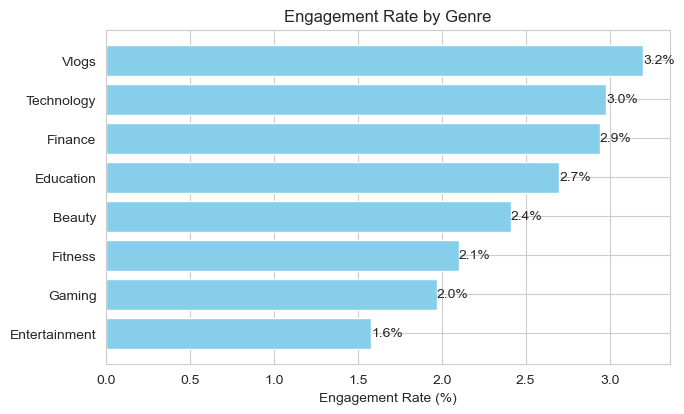

In [284]:

ax1 = plt.subplot(4, 2, 1)

engagement_sorted = genre_metrics.sort_values('avg_engagement_rate', ascending=True)
ax1.barh(engagement_sorted.index, engagement_sorted['avg_engagement_rate'], color='skyblue')

ax1.set_xlabel('Engagement Rate (%)')
ax1.set_title('Engagement Rate by Genre')

for i, v in enumerate(engagement_sorted['avg_engagement_rate']):
    ax1.text(v, i, f'{v:.1f}%', va='center')




### Key Findings

- **Vlogs (3.2%)**  has the **highest engagement rate** which means there is a strong personal connection with audiences.

- **Entertainment (1.6%)** has the **Lowest engagement** despite having high viewership.
  
#### Observations

1. Educational and personal content such Vlogs, Tech, Finance etc. drives higher interaction than entertainment-focused content
2. Genres requiring advice, learning, or personal connection show stronger engagement patterns


### 2. SATURATION INDEX

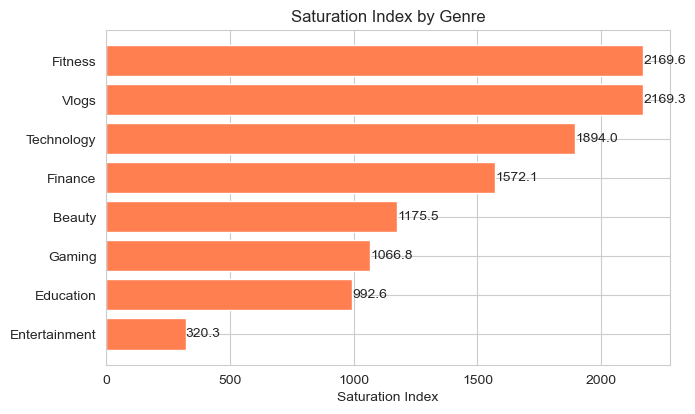

In [285]:
ax2 = plt.subplot(4, 2, 2)

saturation_sorted = genre_metrics.sort_values('saturation_index', ascending=True)
ax2.barh(saturation_sorted.index, saturation_sorted['saturation_index'], color='coral')

ax2.set_xlabel('Saturation Index')
ax2.set_title('Saturation Index by Genre')

for i, v in enumerate(saturation_sorted['saturation_index']):
    ax2.text(v, i, f'{v:.1f}', va='center')

### Key Findings

#### Highly Saturated Genres
- **Fitness (2169.6)** is the most saturated market which implies that their is an intense competition and crowded space.
- **Vlogs (2169.3)** is nearly identical saturation to Fitness implying highly competitive landscape

#### Least Saturated Genre
- **Entertainment (320.3)** shows significantly lower saturation about 6.8x less than Fitness, suggesting there is less competition or a broader category definition

#### Observations

1. Fitness and Vlogs face nearly identical and extreme saturation levels
2. Education and Entertainment show notably lower saturation


### 3. COMPETITION DENSITY

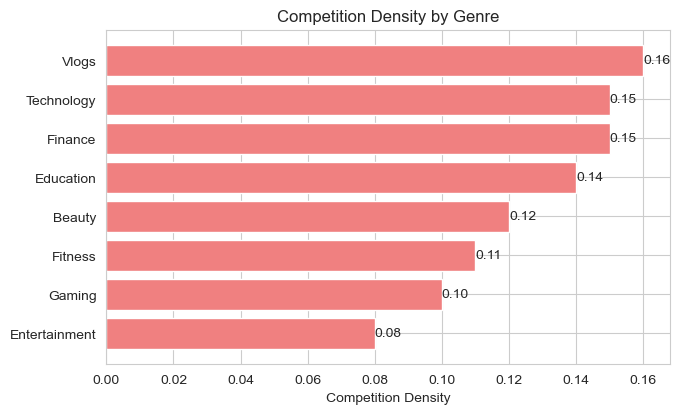

In [286]:
ax3 = plt.subplot(4, 2, 3)

competition_sorted = genre_metrics.sort_values('competition_density', ascending=True)
ax3.barh(competition_sorted.index, competition_sorted['competition_density'], color='lightcoral')

ax3.set_xlabel('Competition Density')
ax3.set_title('Competition Density by Genre')

for i, v in enumerate(competition_sorted['competition_density']):
    ax3.text(v, i, f'{v:.2f}', va='center')


### Key Findings

#### High Competition Genres
- **Vlogs (0.16)** has the highest competition density and most crowded competitive landscape.
- **Technology (0.15)** is the second highest as well as intense competition among tech creators,

#### Lower Competition Genres
- **Gaming (0.10)** has below-average competition despite having a large market size.
- **Entertainment (0.08)** has Lowest competition density and least crowded relative to market.

#### Observations
- Personal content genres like Vlogs, Finance etc., face higher direct competition.
- Entertainment and Gaming show lower density although they are popular categories
- Education maintains moderate-to-high competition levels


### 4. ROI POTENTIAL

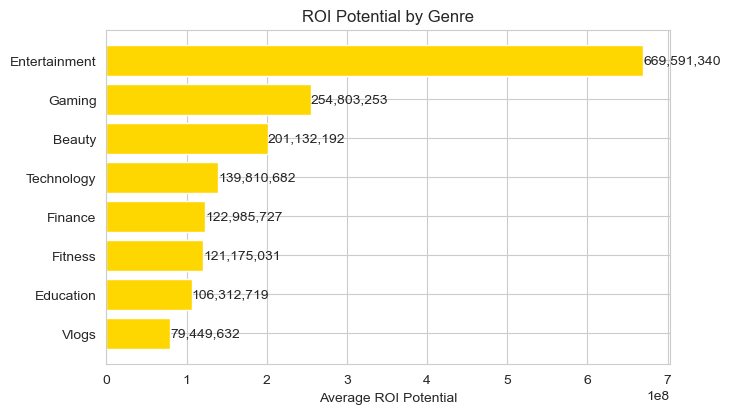

In [287]:
ax4 = plt.subplot(4, 2, 4)

roi_sorted = genre_metrics.sort_values('avg_roi_potential', ascending=True)
ax4.barh(roi_sorted.index, roi_sorted['avg_roi_potential'], color='gold')

ax4.set_xlabel('Average ROI Potential')
ax4.set_title('ROI Potential by Genre')

for i, v in enumerate(roi_sorted['avg_roi_potential']):
    ax4.text(v, i, f'{v:,.0f}', va='center')


### Key Findings

#### High ROI Genres
- **Entertainment (669,591,340)** dominantes the ROI leaderboard.
- **Gaming (254,803,253)** shows strong ROI potential and significantly above other genres.
- **Beauty (201,132,192)** Third highest showing that their is a solid monetization opportunity.

#### Lower ROI Genre
- **Vlogs (79,449,632)** has Lowest ROI potential althought it has the high engagement rates.

#### Observations
1. Entertainment generates 8.4x more ROI than Vlogs
2. Vlogs have highest engagement (3.2%) but lowest ROI
4. Niche genres like Finance, Education show moderate ROI despite having a specialized audiences.
5. Personal contents such as Vlogs struggles with monetization despite having strong engagement.

### 5. BUSINESS SCORE(For bussinesses)

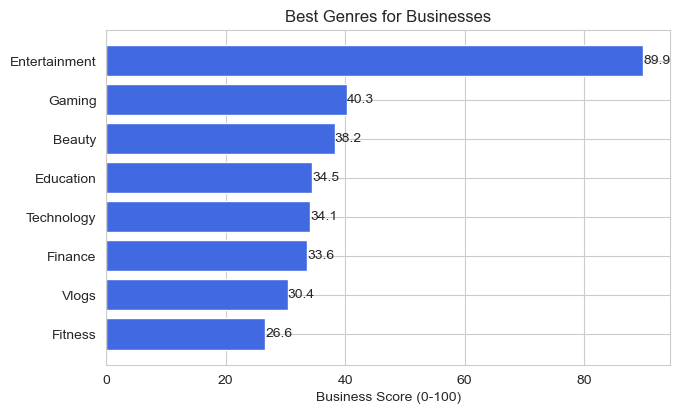

In [302]:
ax5 = plt.subplot(4, 2, 5)

business_sorted = genre_metrics.sort_values('business_score', ascending=True)
ax5.barh(business_sorted.index, business_sorted['business_score'], color='royalblue')

ax5.set_xlabel('Business Score (0-100)')
ax5.set_title('Best Genres for Businesses')

for i, v in enumerate(business_sorted['business_score']):
    ax5.text(v, i, f'{v:.1f}', va='center')

### Key Findings

#### Top Business Opportunities
- **Entertainment (89.9)** leads for business content charts
- **Gaming (40.3)** comes at second showing a moderate business opportunity
- **Beauty (38.2)** comes at third place feasable for product-focused businesses.

#### Lower Business Opportunities
- **Vlogs (30.4)** showes below-average business viability.
- **Fitness (26.6)** has the lowest business score despite its market size.

#### Key Observations
1. Business success correlates more with reach than interaction
4. Entertainment's broad appeal translates to superior business metrics



### Creator Barrier

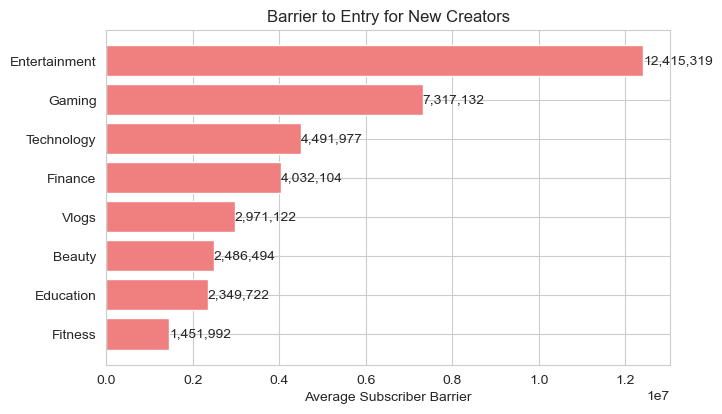

In [303]:
ax6 = plt.subplot(4, 2, 6)

barrier_sorted = genre_metrics.sort_values('creator_barrier', ascending=True)
ax6.barh(barrier_sorted.index, barrier_sorted['creator_barrier'], color='lightcoral')

ax6.set_xlabel('Average Subscriber Barrier')
ax6.set_title('Barrier to Entry for New Creators')

for i, v in enumerate(barrier_sorted['creator_barrier']):
    ax6.text(v, i, f'{v:,.0f}', va='center')

### Key Findings

#### High Barrier Genres (Difficult Entry)
- **Entertainment (12,415,319)** shows highest barrier for aspiring creators which will require massive subscriber base to compete.
- **Gaming (7,317,132)** is the second highest and will need a substantial audience.

#### Low Barrier Genres (Easier Entry)
- **Education (2,349,722)** has a Lower barrier possible for  knowledge-based entry.
- **Fitness (1,451,992)** has the lowest barrier and is the most accessible for new creators.

#### Observations
1. Entertainment requires 8.5x more subscribers than Fitness to compete.
2. High ROI genres like Entertainment, Gaming etc., have the highest entry barriers.
3. Skill-based genres like Fitness, Education have lower barriers



### 7. CREATOR SCORE (Best for New Creators)

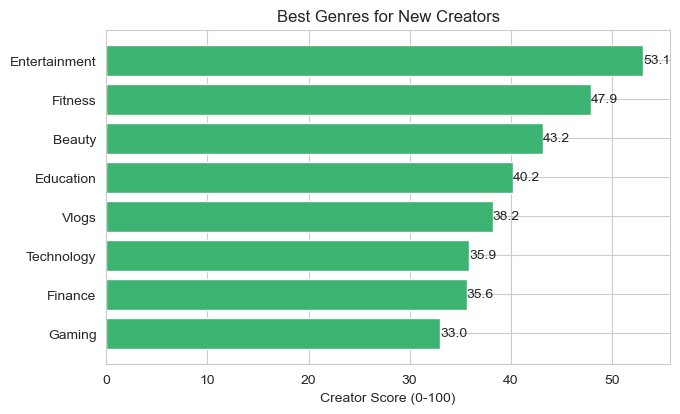

In [304]:
ax7 = plt.subplot(4, 2, 7)

creator_sorted = genre_metrics.sort_values('creator_score', ascending=True)
ax7.barh(creator_sorted.index, creator_sorted['creator_score'], color='mediumseagreen')

ax7.set_xlabel('Creator Score (0-100)')
ax7.set_title('Best Genres for New Creators')

for i, v in enumerate(creator_sorted['creator_score']):
    ax7.text(v, i, f'{v:.1f}', va='center')

### Key Findings

#### Top Creator Opportunities
- **Entertainment (53.1)** has the Best overall opportunity for new creators despite high entry barrier.
- **Fitness (47.9)** secures the second place and gets benefited from lowest entry barrier.
- **Beauty (43.2)** comes third place and shows a balanced opportunity.

#### Lower Creator Opportunity
- **Gaming (33.0)** has the lowest creator score, despite having high business potential, is difficult for new entrants.

#### Observations
1. Entertainment's massive ROI (670M) overcomes its high entry barrier for ambitious creators
2. Fitness offers best risk-reward balance (low barrier + high score)
3. Gaming least favorable for new creators despite commercial success
4. Low barriers don't guarantee high creator scores (e.g Education 40.2 vs Entertainment 53.1)

#### Creator Archetypes
- **High Risk/High Reward**: Entertainment (high barrier, highest score)
- **Balanced Entry**: Fitness, Beauty (moderate barriers, strong scores)
- **Knowledge-Based**: Education (low barrier, moderate score)
- **Avoid for Newcomers**: Gaming (high barrier, lowest score)


### 8. BUSINESS vs CREATOR WINNERS 


✓ Visualization saved as 'genre_analysis.png'


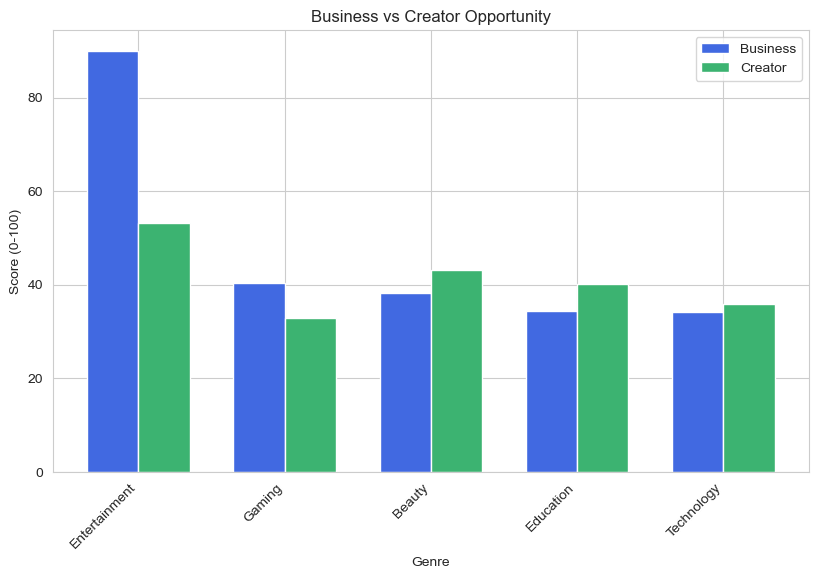

In [305]:
ax8 = plt.subplot(4, 2, 8)

top_genres = genre_metrics.nlargest(5, 'business_score').index
x = np.arange(len(top_genres))
width = 0.35

business_scores = genre_metrics.loc[top_genres, 'business_score']
creator_scores = genre_metrics.loc[top_genres, 'creator_score']


ax8.bar(x - width/2, business_scores, width, label='Business', color='royalblue')
ax8.bar(x + width/2, creator_scores, width, label='Creator', color='mediumseagreen')


ax8.set_xlabel('Genre')
ax8.set_ylabel('Score (0-100)')
ax8.set_title('Business vs Creator Opportunity')
ax8.set_xticks(x)
ax8.set_xticklabels(top_genres, rotation=45, ha='right')
ax8.legend()

plt.tight_layout()
plt.savefig('genre_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved as 'genre_analysis.png'")

### Business vs Creator Opportunity - Key Findings

#### Entertainment
- **Business Score**: 89.9 (Dominant leader) and **Creator Score**: 53.1 (Also highest for creators)
-  Strong for both, but exceptionally better for businesses

#### Gaming
- **Business Score**: 40.3 (Second for businesses) and **Creator Score**: 33.0 (Lowest for creators)
-  Better business opportunity than creator opportunity 

#### Beauty
- **Business Score**: 38.2 (Third for businesses) and **Creator Score**: 43.2 (Third for creators)
- Better for creators than businesses

#### Education
- **Business Score**: 34.5 (Mid-tier for businesses) and **Creator Score**: 40.2 (Fourth for creators)
-  Favors creators over businesses 

#### Technology
- **Business Score**: 34.1 (Similar to Education) and **Creator Score**: 35.9 (Mid-tier for creators)
-  Relatively balanced, slight creator advantage 

#### Fitness
- **Business Score**: 26.6 (Not in top 5 for businesses) and **Creator Score**: 47.9 (Second highest for creators)
- **Pattern**: Major creator advantage but poor business performance

#### Vlogs
- **Business Score**: 30.4 (Not in top 5 for businesses) and **Creator Score**: 38.2 (Fifth for creators)
- Moderate creator advantage

#### Observations

1. Entertainment Leads both categories but business advantage is more pronounced (89.9 vs 53.1)

2. **Opportunities**:
   - Gaming: Better for businesses 
   - Beauty: Better for creators 
   - Fitness: Much better for creators 
   - Education: Better for creators

3. High-volume content like Entertainment, Gaming etc., favors businesses.

4. Lifestyle/personal content like Fitness, Beauty etc., favors individual creators



### 9. Top 3 Genres for Business

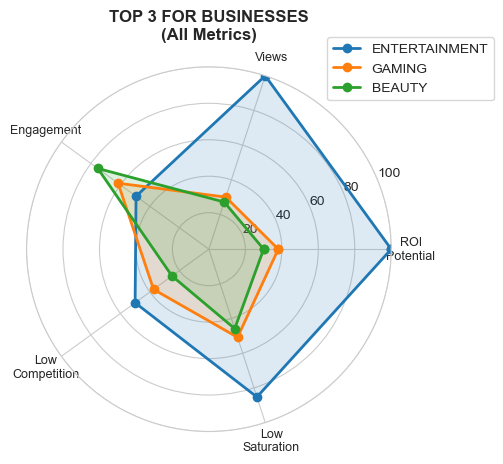

In [306]:
ax_radar1 = plt.subplot(2, 3, 1, projection='polar')

top_3_business = genre_metrics.nlargest(3, 'business_score')

categories = ['ROI\nPotential', 'Views', 'Engagement', 'Low\nCompetition', 'Low\nSaturation']
N = len(categories)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

for idx, genre in enumerate(top_3_business.index):
    values = [
        genre_metrics.loc[genre, 'avg_roi_potential'] / genre_metrics['avg_roi_potential'].max() * 100,
        genre_metrics.loc[genre, 'avg_views'] / genre_metrics['avg_views'].max() * 100,
        genre_metrics.loc[genre, 'avg_engagement_rate'] / genre_metrics['avg_engagement_rate'].max() * 100,
        (1 - genre_metrics.loc[genre, 'competition_density'] / genre_metrics['competition_density'].max()) * 100,
        (1 - genre_metrics.loc[genre, 'saturation_index'] / genre_metrics['saturation_index'].max()) * 100
    ]
    values += values[:1]
    
    ax_radar1.plot(angles, values, 'o-', linewidth=2, label=genre.upper())
    ax_radar1.fill(angles, values, alpha=0.15)

ax_radar1.set_xticks(angles[:-1])
ax_radar1.set_xticklabels(categories, size=9)
ax_radar1.set_ylim(0, 100)
ax_radar1.set_title('TOP 3 FOR BUSINESSES\n(All Metrics)', fontweight='bold', pad=20)
ax_radar1.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax_radar1.grid(True)

###  Key Findings

**Entertainment (Green)** has an extreme reach and monetization with moderate competitive barriers.

**Gaming (Orange)** provides a balance across metrics but show no standout strengths.

**Beauty (Green)** has the high engagement and lower competition, but limited scale.


#### Observations

1.  Entertainment Creates largest radar footprint, particularly strong in Views and ROI

2. 
   - Beauty has the Lowest competition (75/100).
   - Gaming has a Moderate competition (60/100).
   - Entertainment has the highest competition (50/100) , but compensated by superior metrics.

4. 
   - Beauty leads in engagement (75/100)
   - Gaming with a moderate engagement (65/100)
   - Entertainment is the lowest (50/100)

5. Entertainment sacrifices engagement for massive reach; Beauty does opposite

#### Insights
- Entertainment wins through scale despite moderate engagement and high competition
- Gaming offers balanced, consistent performance across all metrics
- Beauty succeeds through niche focus with high engagement and lower barriers
- No genre excels in all 5 dimensions simultaneously

---

### 10. Top 3 Genres for Creators

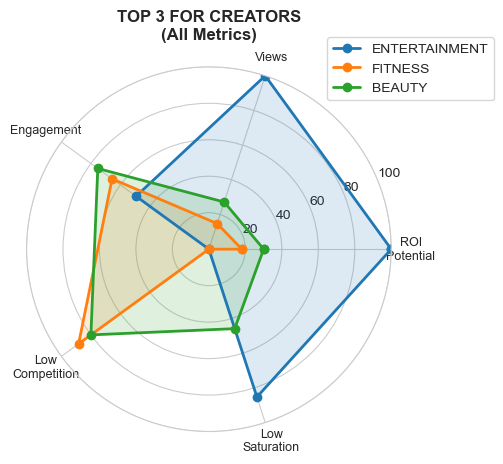

In [307]:
ax_radar2 = plt.subplot(2, 3, 2, projection='polar')

top_3_creators = genre_metrics.nlargest(3, 'creator_score')

for idx, genre in enumerate(top_3_creators.index):
    values = [
        genre_metrics.loc[genre, 'avg_roi_potential'] / genre_metrics['avg_roi_potential'].max() * 100,
        genre_metrics.loc[genre, 'avg_views'] / genre_metrics['avg_views'].max() * 100,
        genre_metrics.loc[genre, 'avg_engagement_rate'] / genre_metrics['avg_engagement_rate'].max() * 100,
        (1 - genre_metrics.loc[genre, 'creator_barrier'] / genre_metrics['creator_barrier'].max()) * 100,
        (1 - genre_metrics.loc[genre, 'saturation_index'] / genre_metrics['saturation_index'].max()) * 100
    ]
    values += values[:1]
    
    ax_radar2.plot(angles, values, 'o-', linewidth=2, label=genre.upper())
    ax_radar2.fill(angles, values, alpha=0.15)

ax_radar2.set_xticks(angles[:-1])
ax_radar2.set_xticklabels(categories, size=9)
ax_radar2.set_ylim(0, 100)
ax_radar2.set_title('TOP 3 FOR CREATORS\n(All Metrics)', fontweight='bold', pad=20)
ax_radar2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax_radar2.grid(True)


### Key Findings


**Entertainment (Blue)** is identical to business chart and has a scale-focused advantage.

**Fitness (Orange)** has easy entry with good engagement but limited monetization scale.

**Beauty (Green)** has high engagement, is accessible entry and has a moderate scale.

#### Observations

1. Entertainment has an Identical profile to business chart. Shows that it is universally strong.

2. **Fitness's Entry Advantage**: 
   - Lowest competition (90/100)—easiest to start
   - Weakest saturation (5/100)—most crowded market overall
   - Is easy to enter, hard to stand out

3. **Beauty's Balanced Profile**:
   - Highest engagement (75/100)
   - Good competition levels (75/100)
   - Moderate saturation (60/100)
   - Consistent mid-tier monetization

4. **Creator-Specific Patterns**:
   - Fitness replaces Gaming from business chart
   - Fitness shows extreme low competition 
   - Engagement becomes more important factor for creators

5. Fitness shows lowest "Low Saturation" score  meaning highest actual saturation, yet it is still ranked #2 for creators due to low barriers.

#### Insights

- **Fitness** is better for creators than businesses 
- **Gaming** is worse for creators  despite having a strong business score (40.3)
-  Low competition matters more for creators than businesses

### 11. Top 5 Rankings Table - Business

Text(0.5, 1.0, 'Top 5 Genres for Businesses')

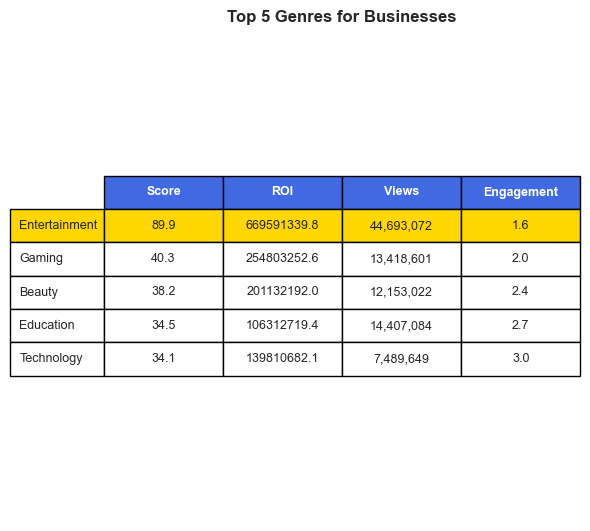

In [309]:

fig = plt.figure(figsize=(18, 12))
fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)
ax_table1 = plt.subplot(2, 3, 4)
ax_table1.axis('tight')
ax_table1.axis('off')

# Get top 5 business genres
top_5_biz = genre_metrics.nlargest(5, 'business_score')[['business_score', 'avg_roi_potential', 'avg_views', 'avg_engagement_rate']]
top_5_biz_display = top_5_biz.copy()
top_5_biz_display.columns = ['Score', 'ROI', 'Views', 'Engagement']
top_5_biz_display = top_5_biz_display.round(1)
top_5_biz_display['Views'] = top_5_biz_display['Views'].apply(lambda x: f'{x:,.0f}')


table1 = ax_table1.table(cellText=top_5_biz_display.values, 
                         colLabels=top_5_biz_display.columns,
                         rowLabels=top_5_biz_display.index,
                         cellLoc='center',
                         loc='center')
table1.auto_set_font_size(False)
table1.set_fontsize(9)
table1.scale(1, 2)

# Highlights header
for i in range(len(top_5_biz_display.columns)):
    table1[(0, i)].set_facecolor('royalblue')
    table1[(0, i)].set_text_props(weight='bold', color='white')

# Highlights top genre (row 1)
for i in range(-1, len(top_5_biz_display.columns)):
    table1[(1, i)].set_facecolor('gold')

ax_table1.set_title('Top 5 Genres for Businesses', fontweight='bold')


### Key Findings

**1. Entertainment(89.9 Score)** is the dominant leader showing massive scale, maximum monetization and lower interaction

**2. Gaming (40.3 Score)** comes at second with Moderate performance across metrics, 2.2x gap from leader.

**3. Beauty (38.2 Score)** shows a balanced metrics and consistent performance

**4. Education (34.5 Score)** have strong views and engagement but these don't translate to top ROI.

**5. Technology (34.1 Score)** has the highest engagement and lowest views—niche audience.

### Observations

1. Entertainment Creates a massive separation from rest of field

2. View volume alone doesn't determine business viability e.g  Education comes 2nd in views (14.4M) but 4th in score (34.5)
   
3. Engagement is Inversely proportionate to score e.g:
   - Entertainment has the Lowest engagement (1.6%) but highest scor and Technology has the highest engagement (3.0%) but lowest score.
   - This suggests that passive viewing generates better business metrics.




### 12. Top 5 Rankings Table - Creators

Text(0.5, 1.0, 'Top 5 Genres for New Creators')

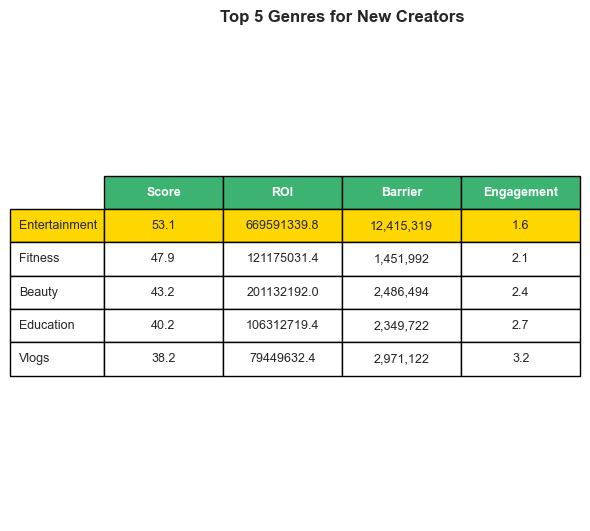

In [311]:

fig = plt.figure(figsize=(18, 12))
fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)
ax_table2 = plt.subplot(2, 3, 5)
ax_table2.axis('tight')
ax_table2.axis('off')

# Gets top 5 creator genres
top_5_creators = genre_metrics.nlargest(5, 'creator_score')[['creator_score', 'avg_roi_potential', 'creator_barrier', 'avg_engagement_rate']]
top_5_creators_display = top_5_creators.copy()
top_5_creators_display.columns = ['Score', 'ROI', 'Barrier', 'Engagement']
top_5_creators_display = top_5_creators_display.round(1)
top_5_creators_display['Barrier'] = top_5_creators_display['Barrier'].apply(lambda x: f'{x:,.0f}')


table2 = ax_table2.table(cellText=top_5_creators_display.values, 
                         colLabels=top_5_creators_display.columns,
                         rowLabels=top_5_creators_display.index,
                         cellLoc='center',
                         loc='center')
table2.auto_set_font_size(False)
table2.set_fontsize(9)
table2.scale(1, 2)


for i in range(len(top_5_creators_display.columns)):
    table2[(0, i)].set_facecolor('mediumseagreen')
    table2[(0, i)].set_text_props(weight='bold', color='white')

for i in range(-1, len(top_5_creators_display.columns)):
    table2[(1, i)].set_facecolor('gold')

ax_table2.set_title('Top 5 Genres for New Creators', fontweight='bold')

### Key Findings


**1. Entertainment (53.1 Score)** is the 'creator leader' which are high risk , but pays off big.

**2. Fitness (47.9 Score)** comes second being the best entry point for new creators but have moderate monetization

**3. Beauty (43.2 Score)** gives a balanced opportunity with solid returns.

**4. Education (40.2 Score)** is a Knowledge-based entry with moderate barriers and returns.

**5. Vlogs (38.2 Score)** has the strongest interaction but weakest monetization.

### Observations

1. Entertainment has the highest score (53.1) despite highest barrier. 
2. Barrier alone doesn't determine creator score, ROI matters more.
3. Engagement isn't primary creator success factor
5. Monetization potential remains critical for creator success

### Insights 

- Barriers matter MORE for creators while Engagement matters less
- ROI is still critical but balanced against entry feasibility



## *Takeaway*
1. **Creators** care about high returns with low effort/risk.

2. **Businesses** care about maximum profit potential, regardless of high costs/risk.



## FINAL Summary

This analysis evaluated 8 YouTube genres to identify optimal opportunities for businesses and content creators.

### Key Findings

**For Businesses:**
- Entertainment is the clear winner (89.9/100), offering 2.2x better performance than any alternative
- All other genres cluster between 26-40, showing similar moderate commercial viability
- ROI potential is the dominant factor driving business success

**For New Creators:**
- Entertainment offers highest returns (53.1/100) but requires significant resources (12.4M subscriber barrier)
- Fitness provides the best entry point (47.9/100) with the lowest barrier (1.45M subscribers)
- Beauty, Education, and Vlogs offer balanced opportunities with moderate barriers and returns

### Critical Insights

1.  Higher engagement doesn't guarantee better monetization.

2. Different Paths for Different Goals: 
   - Gaming favors businesses over creators.
   - Fitness favors creators over businesses 
   - Entertainment leads both categories but with different margins

3.  Low entry barriers don't mean less competition

Entertainment dominates commercial opportunity through scale. 
Creators must balance maximum returns against entry feasibility  based on their resources and risk tolerance.

## *Recommended Actions*

### For Business Stakeholders

- **Investing in Entertainment content** gives a dominant commercial opportunity.
- **Diversify with Gaming + Beauty** can be used against Entertainment's high competition
- Using Gaming for brand partnerships, Beauty for product integration

**Avoid:**
- Fitness, Vlogs, and Finance as it has a limited commercial viability for business investment

---

### For New Content Creators

#### Choose Path Based on Resources:

**High Resources / High Risk Tolerance:**
- **Start with Entertainment** for maximum long-term returns
- It requires significant investment in production quality and audience building

**Low Resources / Risk-Averse:**
- **Start with Fitness** for easiest market entry and focus on strong differentiation due to high saturation

**Balanced Approach:**
- **Choose Beauty or Education** for moderate barriers with solid returns
- Beauty suits visual/product-focused creators and Education suits subject matter experts

### What to Avoid:
- **Gaming as a new creator** as it has a high barrier (7.3M subs) with established player dominance making the entry extremely difficult despite commercial success

---


## *Limitation*

1.  Analysis reflects current market conditions. YouTube trends and algorithms evolve rapidly

2.  Genre-level averages mask sub-niche opportunities within broader categories (e.g., "Gaming" includes mobile, eSports, retro—each with distinct dynamics)

3.  Limited to channels in dataset; may not capture emerging creators or recent market shifts

4.  ROI Assumptions : 
   - Based on views/engagement, not actual revenue data
   - Doesn't account for varying CPM rates, sponsorships, or production costs
   - Represents potential, not guaranteed returns
     
5. YouTube policy changes along with advertiser demand, economic conditions, platform competition etc.,

### Key Cautions

- Scores are relative rankings, not success probabilities
- High ROI attracts competition but doesn't guarantee individual success

Success depends more on execution quality, consistency, and audience connection than genre selection alone. Combine this analysis with market research, competitive analysis, and honest assessment of your capabilities.